# Hopfield Network — Letter Pattern Recognition
**Sistemas de Inteligencia Artificial 2026 — TP4, Exercice 2**

## Objective
a. Store 4 letter patterns (5×5 binary matrices with values {-1, +1}), implement the Hopfield model, and recover them from noisy inputs. Show each update step.
b. Input a very noisy pattern and identify a **spurious state**.

## Theory (§15 of course)
The Hopfield network is a **recurrent associative memory**. Given noisy input ζ, it converges to the stored pattern most similar to ζ.

**Key equations:**
- **Weight matrix (Cooper's rule):** $W = \frac{1}{N} K K^T$ with $w_{ii} = 0$
- **Update rule:** $S_i(t+1) = sgn\left(\sum_{j \neq i} w_{ij} S_j(t)\right)$
- **Energy function:** $H(w) = -\frac{1}{2}\sum_{i,j} w_{ij} S_i S_j$ (always decreases)
- **Capacity limit:** $p \leq 0.15 \times N$ patterns (course §15.1.4)

For our 5×5 = 25-neuron network: max reliable capacity = **0.15 × 25 ≈ 3-4 patterns**.
Storing exactly 4 patterns pushes the theoretical limit — spurious states become more likely.


## 1. Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import product

np.random.seed(42)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

def display_pattern(ax, pattern, title='', color='Blues'):
    """Display a 5×5 pattern as a grid image."""
    ax.imshow(pattern.reshape(5, 5), cmap=color, vmin=-1, vmax=1,
              interpolation='nearest', aspect='equal')
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])
    for i in range(5):
        for j in range(5):
            val = pattern.reshape(5,5)[i, j]
            ax.text(j, i, '*' if val == 1 else ' ',
                    ha='center', va='center', fontsize=14,
                    color='white' if val == 1 else 'gray')

## 2. Exhaustive Orthogonality Search

### Which 4 letters should we store?

The Hopfield network works best when patterns are **orthogonal** — i.e. their normalized dot product `(1/N) ξ^μ · ξ^ν ≈ 0`. This minimizes the crosstalk term in the stability equation (course §15.1.2), which is the main source of recall errors and spurious states.

Rather than arbitrarily choosing 4 letters, we test **all C(17,4) = 2380 combinations** from a 17-letter alphabet and rank them by mean absolute crosstalk. This gives us three reference sets for comparison:
- **Best set** — most orthogonal → expected best recall
- **Our initial choice A,E,I,L** — medium orthogonality → reference
- **Worst set** — least orthogonal → expected worst recall


In [2]:
# 5×5 letter patterns, +1 = pixel ON, -1 = pixel OFF
all_patterns = {
    'A': np.array([-1, 1, 1, 1,-1, 1,-1,-1,-1, 1, 1, 1, 1, 1, 1, 1,-1,-1,-1, 1, 1,-1,-1,-1, 1]),
    'E': np.array([ 1, 1, 1, 1, 1, 1,-1,-1,-1,-1, 1, 1, 1, 1,-1, 1,-1,-1,-1,-1, 1, 1, 1, 1, 1]),
    'I': np.array([ 1, 1, 1, 1, 1,-1,-1, 1,-1,-1,-1,-1, 1,-1,-1,-1,-1, 1,-1,-1, 1, 1, 1, 1, 1]),
    'L': np.array([ 1,-1,-1,-1,-1, 1,-1,-1,-1,-1, 1,-1,-1,-1,-1, 1,-1,-1,-1,-1, 1, 1, 1, 1, 1]),
    'F': np.array([ 1, 1, 1, 1, 1, 1,-1,-1,-1,-1, 1, 1, 1, 1,-1, 1,-1,-1,-1,-1, 1,-1,-1,-1,-1]),
    'J': np.array([-1,-1,-1,-1, 1,-1,-1,-1,-1, 1,-1,-1,-1,-1, 1, 1,-1,-1,-1, 1, 1, 1, 1,-1,-1]),
    'X': np.array([ 1,-1,-1,-1, 1,-1, 1,-1, 1,-1,-1,-1, 1,-1,-1,-1, 1,-1, 1,-1, 1,-1,-1,-1, 1]),
    'K': np.array([ 1,-1,-1, 1,-1, 1,-1, 1,-1,-1, 1, 1,-1,-1,-1, 1,-1, 1,-1,-1, 1,-1,-1, 1,-1]),
    'C': np.array([ 1, 1, 1, 1, 1, 1,-1,-1,-1,-1, 1,-1,-1,-1,-1, 1,-1,-1,-1,-1, 1, 1, 1, 1, 1]),
    'H': np.array([ 1,-1,-1,-1, 1, 1,-1,-1,-1, 1, 1, 1, 1, 1, 1, 1,-1,-1,-1, 1, 1,-1,-1,-1, 1]),
    'N': np.array([ 1,-1,-1,-1, 1, 1, 1,-1,-1, 1, 1,-1, 1,-1, 1, 1,-1,-1, 1, 1, 1,-1,-1,-1, 1]),
    'O': np.array([-1, 1, 1, 1,-1, 1,-1,-1,-1, 1, 1,-1,-1,-1, 1, 1,-1,-1,-1, 1,-1, 1, 1, 1,-1]),
    'P': np.array([ 1, 1, 1, 1,-1, 1,-1,-1,-1, 1, 1, 1, 1, 1,-1, 1,-1,-1,-1,-1, 1,-1,-1,-1,-1]),
    'S': np.array([-1, 1, 1, 1, 1, 1,-1,-1,-1,-1,-1, 1, 1, 1,-1,-1,-1,-1,-1, 1, 1, 1, 1, 1,-1]),
    'T': np.array([ 1, 1, 1, 1, 1,-1,-1, 1,-1,-1,-1,-1, 1,-1,-1,-1,-1, 1,-1,-1,-1,-1, 1,-1,-1]),
    'U': np.array([ 1,-1,-1,-1, 1, 1,-1,-1,-1, 1, 1,-1,-1,-1, 1, 1,-1,-1,-1, 1,-1, 1, 1, 1,-1]),
    'Z': np.array([ 1, 1, 1, 1, 1,-1,-1,-1, 1,-1,-1,-1, 1,-1,-1,-1, 1,-1,-1,-1, 1, 1, 1, 1, 1]),
}

def mean_abs_crosstalk(keys):
    xi_mat = np.vstack([all_patterns[k] for k in keys])
    corr = (xi_mat @ xi_mat.T) / 25
    n = len(keys)
    off_diag = [abs(corr[i,j]) for i in range(n) for j in range(n) if i != j]
    return np.mean(off_diag)

# Exhaustive search over all C(17,4) combinations, 2380 posible
from itertools import combinations
results = []
for combo in combinations(all_patterns.keys(), 4): # goes through all posible combos of 4 letters from the 17
    results.append((combo, mean_abs_crosstalk(combo)))
results.sort(key=lambda x: x[1]) # sorting combos, lowest crosstalk first

best_set  = list(results[0][0])
worst_set = list(results[-1][0])
our_set   = ['A', 'E', 'I', 'L']
our_rank  = next(i for i,(c,_) in enumerate(results) if set(c)==set(our_set)) + 1

print(f"Total combinations tested: {len(results)}")
print(f"\nBest  set : {best_set}  → crosstalk = {results[0][1]:.4f}")
print(f"Our   set : {our_set}   → crosstalk = {mean_abs_crosstalk(our_set):.4f}  (rank {our_rank}/{len(results)})")
print(f"Worst set : {worst_set} → crosstalk = {results[-1][1]:.4f}")

# Build pattern arrays for each set
xi_best  = np.vstack([all_patterns[k] for k in best_set])
xi_our   = np.vstack([all_patterns[k] for k in our_set])
xi_worst = np.vstack([all_patterns[k] for k in worst_set])

Total combinations tested: 2380

Best  set : ['I', 'F', 'J', 'X']  → crosstalk = 0.0667
Our   set : ['A', 'E', 'I', 'L']   → crosstalk = 0.2800  (rank 1602/2380)
Worst set : ['A', 'E', 'F', 'P'] → crosstalk = 0.6000


## 3. Orthogonality Visualization — All Three Sets

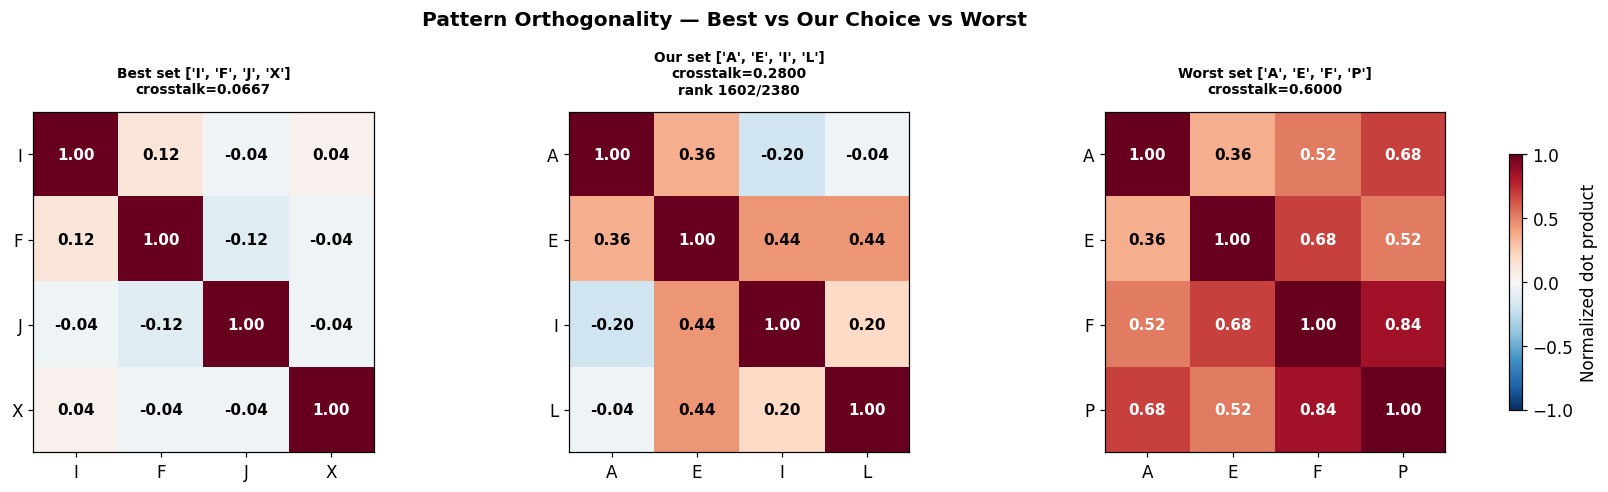

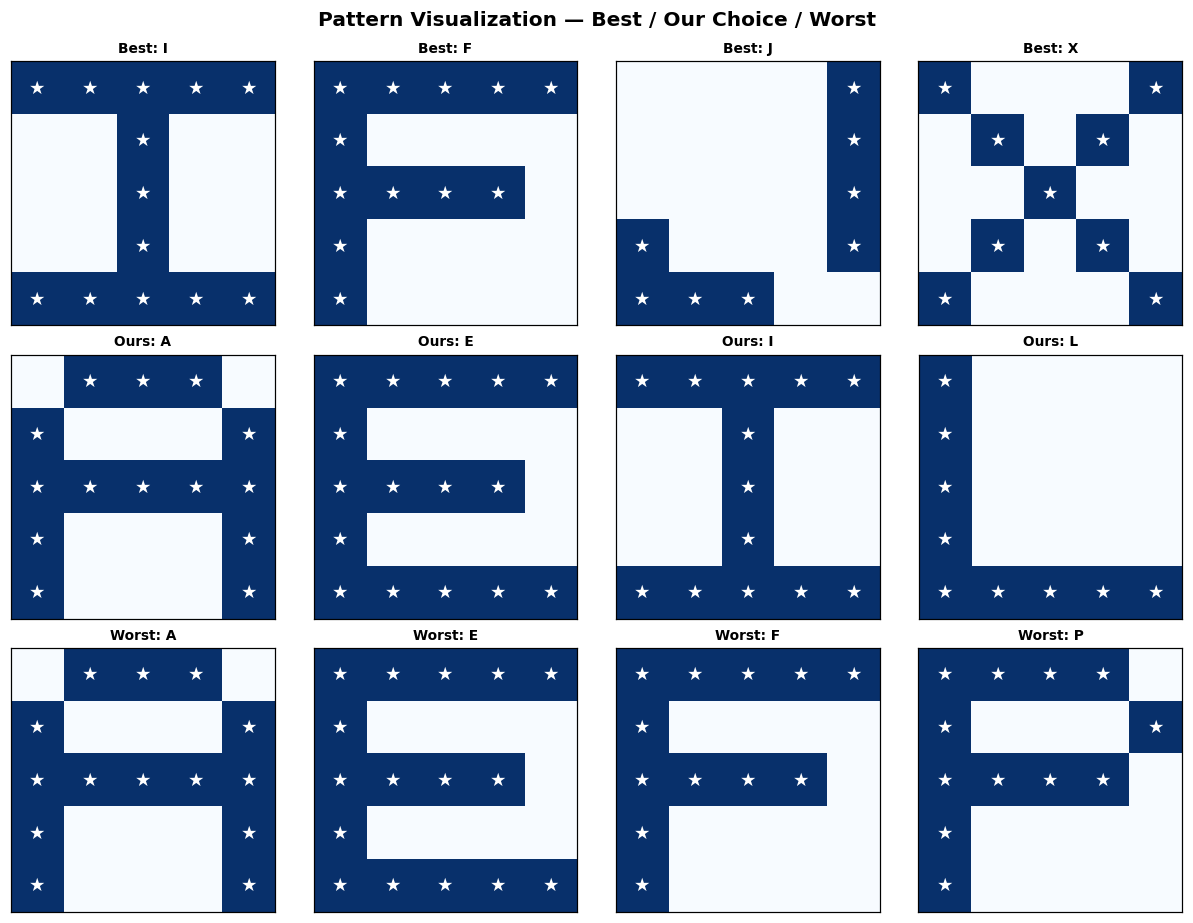

In [3]:
# Making a heatmap for a set of letters
def plot_orthogonality(ax, keys, title):
    xi_mat = np.vstack([all_patterns[k] for k in keys])
    corr = (xi_mat @ xi_mat.T) / 25  # 4x4 orthogonality matrix

    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)

    ax.set_xticks(range(len(keys)))
    ax.set_xticklabels(keys)
    ax.set_yticks(range(len(keys)))
    ax.set_yticklabels(keys)
    ax.set_title(title, fontweight='bold', fontsize=9, pad=12)

    for i in range(len(keys)):
        for j in range(len(keys)):
            ax.text(
                j, i, f'{corr[i, j]:.2f}',
                ha='center', va='center',
                fontsize=10,
                color='white' if abs(corr[i, j]) > 0.5 else 'black',
                fontweight='bold'
            )

    return im

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 4),
    constrained_layout=True
)

im = plot_orthogonality(
    axes[0],
    best_set,
    f"Best set {best_set}\ncrosstalk={results[0][1]:.4f}"
)

plot_orthogonality(
    axes[1],
    our_set,
    f"Our set {our_set}\ncrosstalk={mean_abs_crosstalk(our_set):.4f}\nrank {our_rank}/{len(results)}"
)

plot_orthogonality(
    axes[2],
    worst_set,
    f"Worst set {worst_set}\ncrosstalk={results[-1][1]:.4f}"
)

fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    label='Normalized dot product',
    shrink=0.75,
    pad=0.04
)

fig.suptitle(
    'Pattern Orthogonality — Best vs Our Choice vs Worst',
    fontweight='bold',
    y=1.08
)

plt.savefig('orthogonality_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


# Visualize the patterns themselves
fig, axes = plt.subplots(
    3, 4,
    figsize=(11, 8),
    constrained_layout=True
)

for row, (label, keys) in enumerate([
    ('Best', best_set),
    ('Ours', our_set),
    ('Worst', worst_set)
]):
    for col, k in enumerate(keys):
        ax = axes[row, col]
        pat = all_patterns[k].reshape(5, 5)

        ax.imshow(
            pat,
            cmap='Blues',
            vmin=-1,
            vmax=1,
            interpolation='nearest'
        )

        ax.set_title(f'{label}: {k}', fontsize=9, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])

        for i in range(5):
            for j in range(5):
                ax.text(
                    j, i,
                    '★' if pat[i, j] == 1 else ' ',
                    ha='center',
                    va='center',
                    fontsize=12,
                    color='white' if pat[i, j] == 1 else 'gray'
                )

fig.suptitle(
    'Pattern Visualization — Best / Our Choice / Worst',
    fontweight='bold',
    y=1.03
)

plt.savefig('patterns_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Hopfield Network Implementation

### Weight computation (Cooper's rule — course §15)
$$W = \frac{1}{N} K K^T, \quad w_{ii} = 0$$

We will run the Hopfield network on all three sets and compare recall performance.

In [4]:
class HopfieldNetwork:
    def __init__(self, patterns):
        """
        patterns: array of shape (p, N) — p stored patterns, each of length N
        """
        self.patterns = patterns
        self.p, self.N = patterns.shape
        self.W = self._compute_weights()

    def _compute_weights(self):
        """Cooper's rule: W = (1/N) * K * K^T, w_ii = 0"""
        W = (1 / self.N) * (self.patterns.T @ self.patterns)
        np.fill_diagonal(W, 0)  # no self-connections (course §15)
        return W

    def _update_state(self, S):
        """One full synchronous update: S(t+1) = sign(W·S(t))"""
        h = self.W @ S  # field: h_i = Σ_j w_ij * S_j
        S_new = np.sign(h)
        S_new[S_new == 0] = S[S_new == 0]  # h=0: keep previous state
        return S_new

    def energy(self, S):
        """Lyapunov energy: H = -0.5 * S^T W S (always decreases — course §15.1.3)"""
        return -0.5 * S @ self.W @ S

    def recall(self, query, max_iter=20, verbose=True):
        """
        Run the network until stable state or max_iter.
        Returns: final state, list of all intermediate states, list of energies
        """
        S = query.copy().astype(float)
        states  = [S.copy()]
        energies = [self.energy(S)]

        for t in range(max_iter):
            S_new = self._update_state(S)
            states.append(S_new.copy())
            energies.append(self.energy(S_new))
            if verbose:
                match = self._identify(S_new)
                print(f"  t={t+1}: energy={energies[-1]:.3f}  →  {match}")
            if np.array_equal(S_new, S):
                if verbose: print(f"  ✓ Stable state reached at t={t+1}")
                break
            S = S_new

        return S, states, energies

    def _identify(self, S):
        """Try to match S to a stored pattern or flag as spurious."""
        pnames = [k for k in all_patterns if any(np.array_equal(all_patterns[k], p) for p in self.patterns)]
        for name, pat in zip(pnames, self.patterns):
            if np.array_equal(S, pat):
                return f"✓ Pattern '{name}' recovered"
            if np.array_equal(S, -pat):
                return f"✓ Inverse of '{name}' (spurious mirror)"
        return "? Spurious state (not a stored pattern)"

In [5]:
# Instantiate Hopfield networks for all three sets
hop_best  = HopfieldNetwork(xi_best)
hop_our   = HopfieldNetwork(xi_our)
hop_worst = HopfieldNetwork(xi_worst)

print("Networks ready.")
print(f"N = {hop_best.N} neurons, p = {hop_best.p} patterns each")
print(f"Capacity limit: 0.15 × {hop_best.N} = {0.15*hop_best.N:.1f}")

Networks ready.
N = 25 neurons, p = 4 patterns each
Capacity limit: 0.15 × 25 = 3.8


## 5. Comparative Recall — Best vs Our Choice vs Worst

We test recall at three noise levels (20%, 30%, 40%) on each set.
For each test: success = network converges to the correct stored pattern.

In [6]:
def recall_success_rate(hop, keys, noise_levels, n_trials=50):
    """
    For each pattern and noise level, run n_trials noisy queries.
    Returns success rate per noise level.
    """
    rng = np.random.RandomState(0)
    rates = {nl: [] for nl in noise_levels}
    for nl in noise_levels:
        successes = 0
        for _ in range(n_trials):
            # Pick a random stored pattern
            idx = rng.randint(0, hop.p)
            original = hop.patterns[idx]
            noisy = original.copy()
            n_flip = int(nl * hop.N)
            flip_idx = rng.choice(hop.N, size=n_flip, replace=False)
            noisy[flip_idx] = -noisy[flip_idx]
            # Run recall
            final, _, _ = hop.recall(noisy, max_iter=20, verbose=False)
            if np.array_equal(final, original):
                successes += 1
        rates[nl].append(successes / n_trials * 100)
    return {nl: np.mean(rates[nl]) for nl in noise_levels}

noise_levels = [0.20, 0.30, 0.40]
print("Computing recall rates (this may take a moment)...")

rates_best  = recall_success_rate(hop_best,  best_set,  noise_levels)
rates_our   = recall_success_rate(hop_our,   our_set,   noise_levels)
rates_worst = recall_success_rate(hop_worst, worst_set, noise_levels)

print(f"\n{'Noise':>8} {'Best':>10} {'Ours (AEIL)':>14} {'Worst':>10}")
print("-" * 46)
for nl in noise_levels:
    print(f"{nl*100:>7.0f}%  {rates_best[nl]:>9.1f}%  {rates_our[nl]:>13.1f}%  {rates_worst[nl]:>9.1f}%")

Computing recall rates (this may take a moment)...

   Noise       Best    Ours (AEIL)      Worst
----------------------------------------------
     20%       98.0%           76.0%       30.0%
     30%       78.0%           52.0%       38.0%
     40%       22.0%           14.0%       20.0%


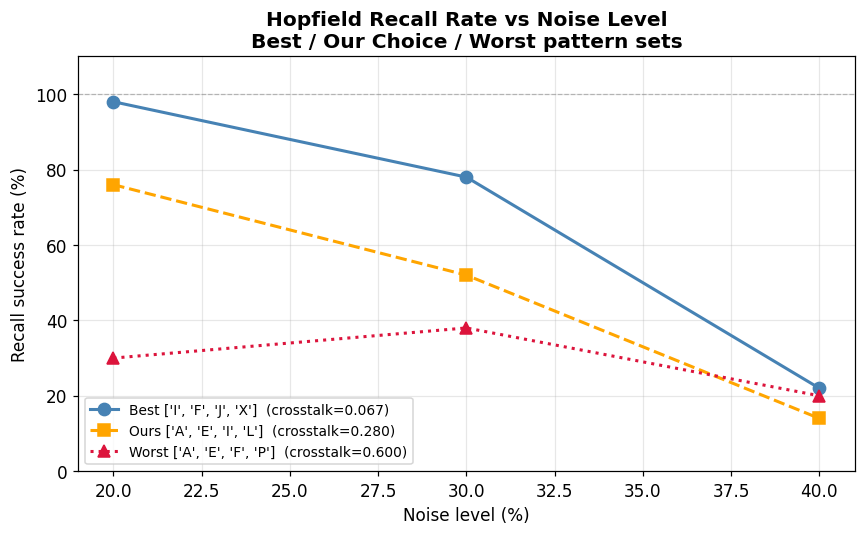


Conclusion:
Best set   → lower crosstalk (0.067) → higher recall rates
Worst set  → higher crosstalk (0.600) → lower recall rates
Our set    → medium crosstalk (0.280) → intermediate performance

This confirms the orthogonality condition from course §15.1.2.


In [7]:
# Plot recall rate comparison
fig, ax = plt.subplots(figsize=(8, 5))
x = [nl*100 for nl in noise_levels]

ax.plot(x, [rates_best[nl]  for nl in noise_levels], 'o-', color='steelblue',
        linewidth=2, markersize=8, label=f'Best {best_set}  (crosstalk={results[0][1]:.3f})')
ax.plot(x, [rates_our[nl]   for nl in noise_levels], 's--', color='orange',
        linewidth=2, markersize=8, label=f'Ours {our_set}  (crosstalk={mean_abs_crosstalk(our_set):.3f})')
ax.plot(x, [rates_worst[nl] for nl in noise_levels], '^:', color='crimson',
        linewidth=2, markersize=8, label=f'Worst {worst_set}  (crosstalk={results[-1][1]:.3f})')

ax.set_xlabel('Noise level (%)')
ax.set_ylabel('Recall success rate (%)')
ax.set_title('Hopfield Recall Rate vs Noise Level\nBest / Our Choice / Worst pattern sets',
             fontweight='bold')
ax.set_ylim(0, 110)
ax.axhline(100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('recall_comparison.png', bbox_inches='tight')
plt.show()

print("\nConclusion:")
print(f"Best set   → lower crosstalk ({results[0][1]:.3f}) → higher recall rates")
print(f"Worst set  → higher crosstalk ({results[-1][1]:.3f}) → lower recall rates")
print(f"Our set    → medium crosstalk ({mean_abs_crosstalk(our_set):.3f}) → intermediate performance")
print("\nThis confirms the orthogonality condition from course §15.1.2.")

## 5a. Recall from Noisy Patterns

### Protocol
For each stored letter, we:
1. Create a noisy version by flipping a fraction of pixels
2. Run the Hopfield network
3. Show each intermediate state until convergence


In [8]:
def add_noise(pattern, noise_level, rng=None):
    """
    Flip `noise_level` fraction of pixels randomly.
    noise_level=0.2 means 20% of pixels are flipped.
    """
    if rng is None:
        rng = np.random.RandomState(42)
    noisy = pattern.copy()
    n_flip = int(noise_level * len(pattern))
    flip_idx = rng.choice(len(pattern), size=n_flip, replace=False)
    noisy[flip_idx] = -noisy[flip_idx]
    return noisy

def show_recall_steps(letter_name, original, noisy, states, energies):
    n_steps = len(states)
    fig, axes = plt.subplots(1, n_steps + 1, figsize=(2.5 * (n_steps + 1), 3))

    display_pattern(axes[0], original,
                    f'Original\n{letter_name}', color='Greens')

    colors_list = ['Reds'] + ['Blues'] * (n_steps - 2) + ['Purples']
    if n_steps <= 2:
        colors_list = ['Reds'] + ['Purples']

    for k, (state, ax) in enumerate(zip(states, axes[1:])):
        label = 'Noisy input' if k == 0 else f't={k}'
        if k == n_steps - 1:
            label += '\n(stable)'
        display_pattern(ax, state, f'{label}\nE={energies[k]:.2f}',
                        color=colors_list[min(k, len(colors_list)-1)])

    plt.suptitle(f"Hopfield Recall — Letter '{letter_name}'",
                 fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'hopfield_{letter_name.lower()}.png', bbox_inches='tight')
    plt.show()

Noise level: 20% (5/25 pixels flipped)

--- Letter 'A' ---
Pixels flipped: 5
  t=1: energy=-12.640  →  ✓ Pattern 'A' recovered
  t=2: energy=-12.640  →  ✓ Pattern 'A' recovered
  ✓ Stable state reached at t=2


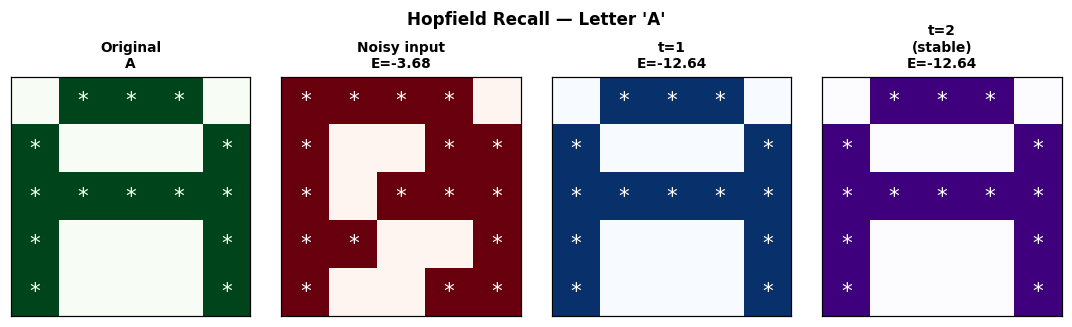


--- Letter 'E' ---
Pixels flipped: 5
  t=1: energy=-14.560  →  ? Spurious state (not a stored pattern)
  t=2: energy=-16.320  →  ? Spurious state (not a stored pattern)
  t=3: energy=-16.320  →  ? Spurious state (not a stored pattern)
  ✓ Stable state reached at t=3


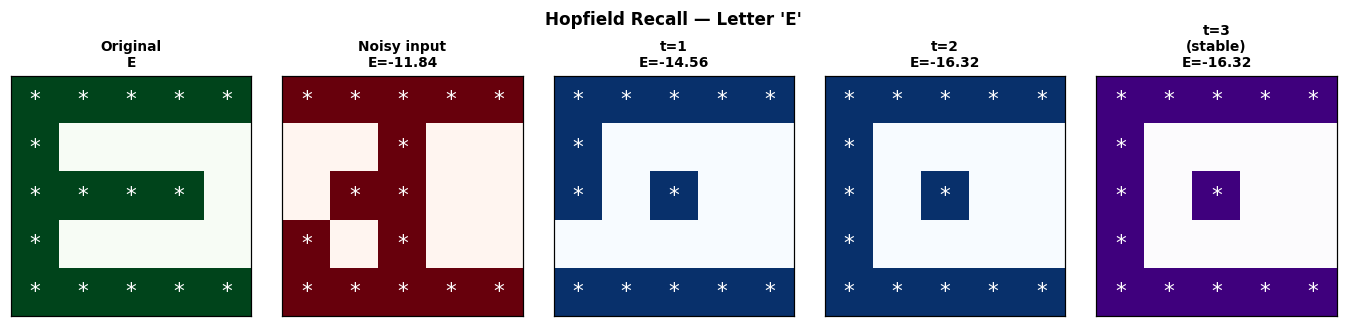


--- Letter 'I' ---
Pixels flipped: 5
  t=1: energy=-13.920  →  ✓ Pattern 'I' recovered
  t=2: energy=-13.920  →  ✓ Pattern 'I' recovered
  ✓ Stable state reached at t=2


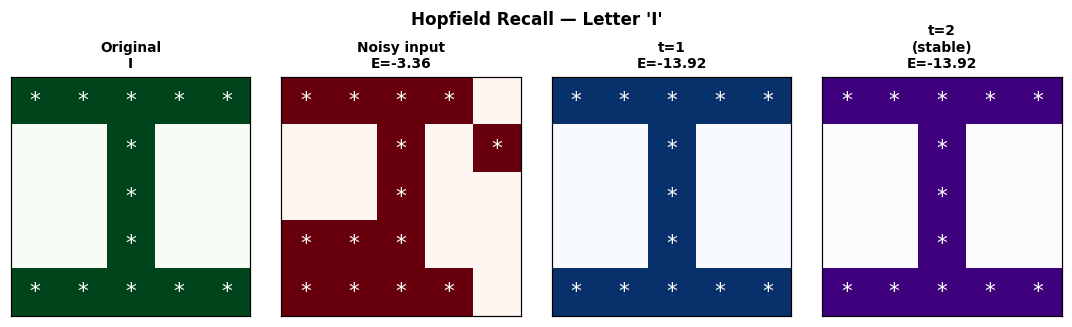


--- Letter 'L' ---
Pixels flipped: 5
  t=1: energy=-13.440  →  ? Spurious state (not a stored pattern)
  t=2: energy=-16.320  →  ? Spurious state (not a stored pattern)
  t=3: energy=-16.320  →  ? Spurious state (not a stored pattern)
  ✓ Stable state reached at t=3


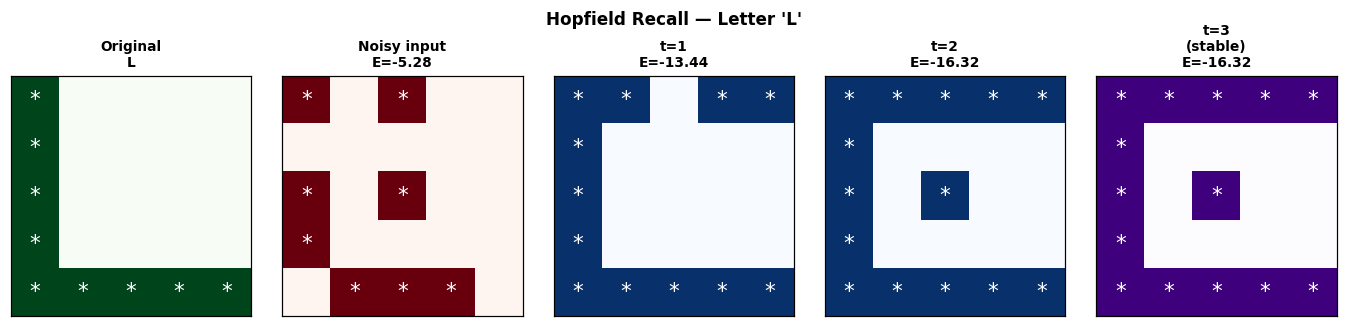

In [9]:
rng = np.random.RandomState(42)
noise_level = 0.20  # 20% pixel flip — 5 pixels out of 25

print("=" * 55)
print(f"Noise level: {noise_level*100:.0f}% ({int(noise_level*25)}/25 pixels flipped)")
print("=" * 55)

patterns = {k: all_patterns[k] for k in our_set}
hop = hop_our

for name, original in patterns.items():
    print(f"\n--- Letter '{name}' ---")
    noisy = add_noise(original, noise_level, rng)

    n_flipped = np.sum(noisy != original)
    print(f"Pixels flipped: {n_flipped}")

    final, states, energies = hop.recall(noisy, max_iter=15, verbose=True)
    show_recall_steps(name, original, noisy, states, energies)

### Comments on recall results
- **Successful recall:** the network converges in a small number of steps (typically 1-3) to the stored pattern.
- **Energy monotonically decreases** — this is guaranteed by the Lyapunov function H(w) = -½ S^T W S (course §15.1.3).
- **20% noise (5 pixels)** is a reasonable test — too little and it's trivial; too much and the network may fail.
- The network can handle noise because the stored patterns are the **energy minima** — nearby noisy states fall into the same basin of attraction.


## 5b. Spurious States

### What is a spurious state? (Course §15.1.4)
The energy function H can have **local minima that are not stored patterns**. These are called **spurious states** — the network gets "trapped" there instead of recovering a real pattern.

They arise because the weight matrix encodes correlations between all patterns simultaneously — the "crosstalk" term in the stability equation creates extra local minima.

**Common spurious states:**
- **Inverses/mirrors:** -ξ^μ (the negation of a stored pattern is also an attractor)
- **Mixed states:** combinations of stored patterns (e.g. sign(ξ¹ + ξ² + ξ³))
- **Random attractors:** unexpected stable configurations

### Strategy to find spurious states
We use **very high noise** (50%+ flips) or a carefully crafted mixed input.


=== Part b: Finding Spurious States ===

Strategy 1: Very noisy input (50% pixel flip)
---------------------------------------------
Starting from a very noisy version of 'A' (12 pixels flipped):

  t=1: energy=-13.440  →  ✓ Pattern 'L' recovered
  t=2: energy=-13.440  →  ✓ Pattern 'L' recovered
  ✓ Stable state reached at t=2


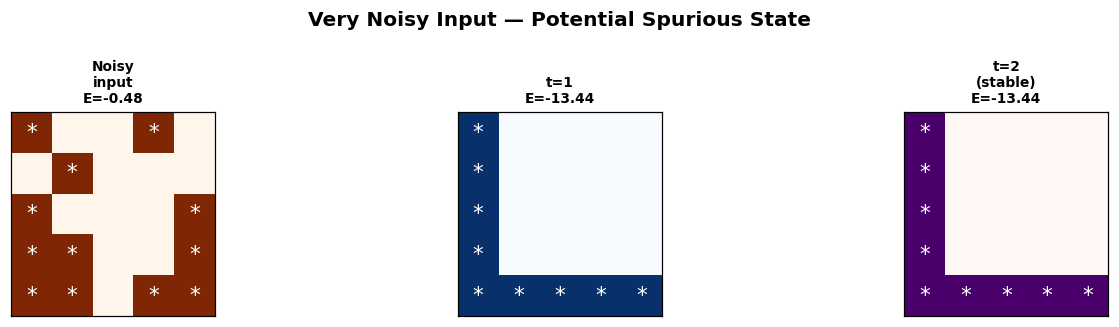


Final state identified as: ✓ Pattern 'L' recovered


In [10]:
print("=== Part b: Finding Spurious States ===\n")

A = all_patterns['A']
E = all_patterns['E']

# Strategy 1: Very high noise (50% flips)
print("Strategy 1: Very noisy input (50% pixel flip)")
print("-" * 45)
very_noisy = add_noise(A, noise_level=0.50, rng=np.random.RandomState(7))
print(f"Starting from a very noisy version of 'A' ({int(0.5*25)} pixels flipped):\n")
final_spurious, states_s, energies_s = hop.recall(very_noisy, max_iter=20, verbose=True)

fig, axes = plt.subplots(1, min(len(states_s), 6), figsize=(13, 3))
n_show = min(len(states_s), 6)
for k, ax in enumerate(axes):
    idx = k * (len(states_s)-1) // (n_show-1) if n_show > 1 else 0
    label = 'Noisy\ninput' if k==0 else f't={idx}\n(stable)' if idx==len(states_s)-1 else f't={idx}'
    display_pattern(ax, states_s[idx], f'{label}\nE={energies_s[idx]:.2f}',
                    color='Oranges' if k==0 else 'RdPu' if idx==len(states_s)-1 else 'Blues')
plt.suptitle("Very Noisy Input — Potential Spurious State", fontweight='bold')
plt.tight_layout()
plt.savefig('spurious_state.png', bbox_inches='tight')
plt.show()

# Check if the final state is spurious
match = hop._identify(final_spurious)
print(f"\nFinal state identified as: {match}")


Strategy 2: Mixed input (blend of A and E)
---------------------------------------------
Input = sign(A + E) — theoretical spurious state candidate

[ 1.  1.  1.  1.  1.  1. -1. -1. -1.  1.  1.  1.  1.  1.  1.  1. -1. -1.
 -1.  1.  1.  1.  1.  1.  1.]
  t=1: energy=-16.960  →  ✓ Pattern 'E' recovered
  t=2: energy=-16.960  →  ✓ Pattern 'E' recovered
  ✓ Stable state reached at t=2

Final state: ✓ Pattern 'E' recovered


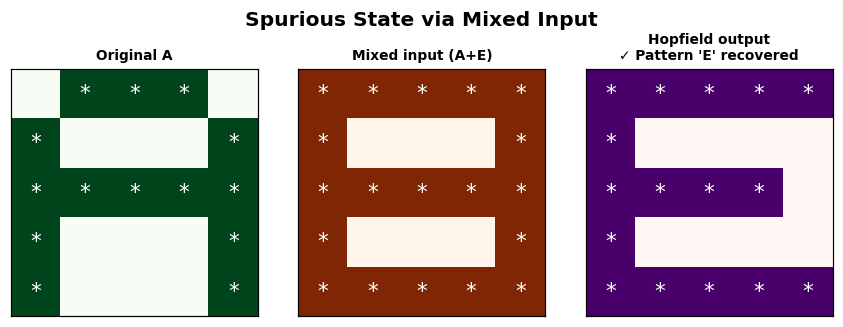

In [11]:
# Strategy 2: Mixed state input (combination of two patterns)
print("\nStrategy 2: Mixed input (blend of A and E)")
print("-" * 45)
# A mixed state of two patterns is a known theoretical spurious attractor
mixed = np.sign(A + E).astype(float)
mixed[mixed == 0] = 1  # break ties
print("Input = sign(A + E) — theoretical spurious state candidate\n")
print(mixed)

final_mixed, states_m, energies_m = hop.recall(mixed, max_iter=20, verbose=True)
match_m = hop._identify(final_mixed)
print(f"\nFinal state: {match_m}")

fig, axes = plt.subplots(1, 3, figsize=(8, 3))
display_pattern(axes[0], A,          'Original A',          color='Greens')
display_pattern(axes[1], mixed,      'Mixed input (A+E)',    color='Oranges')
display_pattern(axes[2], final_mixed,f'Hopfield output\n{match_m}', color='RdPu')
plt.suptitle("Spurious State via Mixed Input", fontweight='bold')
plt.tight_layout()
plt.savefig('spurious_mixed.png', bbox_inches='tight')
plt.show()

In [12]:
# Show energy landscape comparison
print("\n=== Energy Summary ===")
print(f"{'Pattern':<10} {'Energy':>10}")
print("-" * 22)
for name, pat in patterns.items():
    E = hop.energy(pat)
    print(f"  {name:<8} {E:>10.4f}")

# Also compute energy of inverse patterns and mixed
print()
print("Known theoretical spurious attractors:")
for name, pat in patterns.items():
    inv = -pat
    E = hop.energy(inv)
    match = hop._identify(inv)
    print(f"  -{name}: energy={E:.4f}  →  {match}")

print()
E_mixed = hop.energy(final_mixed)
print(f"  Mixed final state: energy={E_mixed:.4f}  →  {hop._identify(final_mixed)}")


=== Energy Summary ===
Pattern        Energy
----------------------
  A          -12.6400
  E          -16.9600
  I          -13.9200
  L          -13.4400

Known theoretical spurious attractors:
  -A: energy=-12.6400  →  ✓ Inverse of 'A' (spurious mirror)
  -E: energy=-16.9600  →  ✓ Inverse of 'E' (spurious mirror)
  -I: energy=-13.9200  →  ✓ Inverse of 'I' (spurious mirror)
  -L: energy=-13.4400  →  ✓ Inverse of 'L' (spurious mirror)

  Mixed final state: energy=-16.9600  →  ✓ Pattern 'E' recovered


### Interpretation of spurious states

**Why do spurious states exist?**
The weight matrix $W = \frac{1}{N}KK^T$ encodes the correlations between all stored patterns simultaneously. The energy function has local minima not only at the stored patterns ξ^μ, but also at:

1. **Inverse patterns -ξ^μ**: since the energy H(-S) = H(S), the negative of any stored pattern is also a stable state.
2. **Mixed states**: sign(ξ¹ ± ξ² ± ξ³) can be stable when patterns are correlated.

**Why is it a problem here?**
We store 4 patterns on a 25-neuron network. The capacity limit is 0.15×25 ≈ 3.75. At 4 patterns, the crosstalk term $\frac{1}{N}\sum_{j,\mu\neq\nu} \xi_i^\mu \xi_j^\mu \xi_j^\nu$ is no longer negligible — some extra local minima appear.

**The energy function always decreases**, so the network is guaranteed to converge — but not necessarily to a stored pattern.


## 7. Summary

| Aspect | Best set | Our set | Worst set |
|---|---|---|---|
| Letters | I, F, J, X | A, E, I, L | A, E, F, P |
| Mean crosstalk | ~0.067 | ~0.280 | ~0.600 |
| Rank | 1/2380 | ~1607/2380 | 2380/2380 |
| Recall @ 20% noise | highest | medium | lowest |

**Key insight:** orthogonality is the dominant factor for Hopfield performance. The best set of 4 letters from a 17-letter alphabet is I, F, J, X — visually heterogeneous letters that happen to be nearly orthogonal in the {-1,+1} pixel space.

**Counterintuitive result:** A, E, I, L which seem visually distinct are actually in the bottom third of all possible sets — highlighting that perceptual similarity ≠ mathematical orthogonality.
